In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet

import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving stores_sales_forecasting.csv to stores_sales_forecasting.csv


In [14]:
sales_df = pd.read_csv('stores_sales_forecasting.csv', encoding='latin1')

In [15]:
sales_df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,9963,CA-2015-168088,3/19/2015,3/22/2015,First Class,CM-12655,Corinna Mitchell,Home Office,United States,Houston,...,77041,Central,FUR-BO-10004218,Furniture,Bookcases,Bush Heritage Pine Collection 5-Shelf Bookcase...,383.4656,4,0.32,-67.6704
2117,9965,CA-2016-146374,12/5/2016,12/10/2016,Second Class,HE-14800,Harold Engle,Corporate,United States,Newark,...,19711,East,FUR-FU-10002671,Furniture,Furnishings,Electrix 20W Halogen Replacement Bulb for Zoom...,13.4000,1,0.00,6.4320
2118,9981,US-2015-151435,9/6/2015,9/9/2015,Second Class,SW-20455,Shaun Weien,Consumer,United States,Lafayette,...,70506,South,FUR-TA-10001039,Furniture,Tables,KI Adjustable-Height Table,85.9800,1,0.00,22.3548
2119,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028


In [16]:
sales_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [17]:
sales_df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2116,9963,CA-2015-168088,3/19/2015,3/22/2015,First Class,CM-12655,Corinna Mitchell,Home Office,United States,Houston,...,77041,Central,FUR-BO-10004218,Furniture,Bookcases,Bush Heritage Pine Collection 5-Shelf Bookcase...,383.4656,4,0.32,-67.6704
2117,9965,CA-2016-146374,12/5/2016,12/10/2016,Second Class,HE-14800,Harold Engle,Corporate,United States,Newark,...,19711,East,FUR-FU-10002671,Furniture,Furnishings,Electrix 20W Halogen Replacement Bulb for Zoom...,13.4000,1,0.00,6.4320
2118,9981,US-2015-151435,9/6/2015,9/9/2015,Second Class,SW-20455,Shaun Weien,Consumer,United States,Lafayette,...,70506,South,FUR-TA-10001039,Furniture,Tables,KI Adjustable-Height Table,85.9800,1,0.00,22.3548
2119,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
2120,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332


In [18]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   object 
 2   Order Date     2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   Ship Mode      2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          2121 non-null   object 
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   object 
 13  Product ID     2121 non-null   object 
 14  Category       2121 non-null   object 
 15  Sub-Category   2121 non-null   object 
 16  Product Name   2121 non-null   object 
 17  Sales          2121 non-null   float64
 18  Quantity

In [19]:
sales_df.value_counts

<bound method DataFrame.value_counts of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1          2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
3          6  CA-2014-115812    6/9/2014   6/14/2014  Standard Class   
4         11  CA-2014-115812    6/9/2014   6/14/2014  Standard Class   
...      ...             ...         ...         ...             ...   
2116    9963  CA-2015-168088   3/19/2015   3/22/2015     First Class   
2117    9965  CA-2016-146374   12/5/2016  12/10/2016    Second Class   
2118    9981  US-2015-151435    9/6/2015    9/9/2015    Second Class   
2119    9990  CA-2014-110422   1/21/2014   1/23/2014    Second Class   
2120    9991  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   

     Customer ID     Customer Name      Segment        Country  \
0       CG-12520       Claire Gute     Consumer  United States   
1       CG-12520       Claire Gute     Consumer  United States   
2       SO-20335    Sean O'Donnell     Consumer  United States   
3       BH-11710   Brosina Hoffman     Consumer  United States   
4       BH-11710   Brosina Hoffman     Consumer  United States   
...          ...               ...          ...            ...   
2116    CM-12655  Corinna Mitchell  Home Office  United States   
2117    HE-14800      Harold Engle    Corporate  United States   
2118    SW-20455       Shaun Weien     Consumer  United States   
2119    TB-21400  Tom Boeckenhauer     Consumer  United States   
2120    DB-13060       Dave Brooks     Consumer  United States   

                 City  ... Postal Code   Region       Product ID   Category  \
0           Henderson  ...       42420    South  FUR-BO-10001798  Furniture   
1           Henderson  ...       42420    South  FUR-CH-10000454  Furniture   
2     Fort Lauderdale  ...       33311    South  FUR-TA-10000577  Furniture   
3         Los Angeles  ...       90032     West  FUR-FU-10001487  Furniture   
4         Los Angeles  ...       90032     West  FUR-TA-10001539  Furniture   
...               ...  ...         ...      ...              ...        ...   
2116          Houston  ...       77041  Central  FUR-BO-10004218  Furniture   
2117           Newark  ...       19711     East  FUR-FU-10002671  Furniture   
2118        Lafayette  ...       70506    South  FUR-TA-10001039  Furniture   
2119            Miami  ...       33180    South  FUR-FU-10001889  Furniture   
2120       Costa Mesa  ...       92627     West  FUR-FU-10000747  Furniture   

     Sub-Category                                       Product Name  \
0       Bookcases                  Bush Somerset Collection Bookcase   
1          Chairs  Hon Deluxe Fabric Upholstered Stacking Chairs,...   
2          Tables      Bretford CR4500 Series Slim Rectangular Table   
3     Furnishings  Eldon Expressions Wood and Plastic Desk Access...   
4          Tables           Chromcraft Rectangular Conference Tables   
...           ...                                                ...   
2116    Bookcases  Bush Heritage Pine Collection 5-Shelf Bookcase...   
2117  Furnishings  Electrix 20W Halogen Replacement Bulb for Zoom...   
2118       Tables                         KI Adjustable-Height Table   
2119  Furnishings                             Ultra Door Pull Handle   
2120  Furnishings  Tenex B1-RE Series Chair Mats for Low Pile Car...   

          Sales  Quantity  Discount    Profit  
0      261.9600         2      0.00   41.9136  
1      731.9400         3      0.00  219.5820  
2      957.5775         5      0.45 -383.0310  
3       48.8600         7      0.00   14.1694  
4     1706.1840         9      0.20   85.3092  
...         ...       ...       ...       ...  
2116   383.4656         4      0.32  -67.6704  
2117    13.4000         1      0.00    6.4320  
2118    85.9800         1      0.00   22.3548  
2119    

In [20]:
sales_df['Order Date'] = pd.to_datetime(sales_df['Order Date'])

In [21]:
sales_df = sales_df.sort_values('Order Date')

In [22]:
sales_data = sales_df.groupby('Order Date').agg({
    'Sales': 'sum',
    'Discount': 'mean',
    'Quantity': 'sum'
}).reset_index()



In [23]:
print(sales_data.head())

  Order Date     Sales  Discount  Quantity
0 2014-01-06  2573.820     0.000         9
1 2014-01-07    76.728     0.600         3
2 2014-01-10    51.940     0.000         1
3 2014-01-11     9.940     0.000         2
4 2014-01-13   879.939     0.075         9


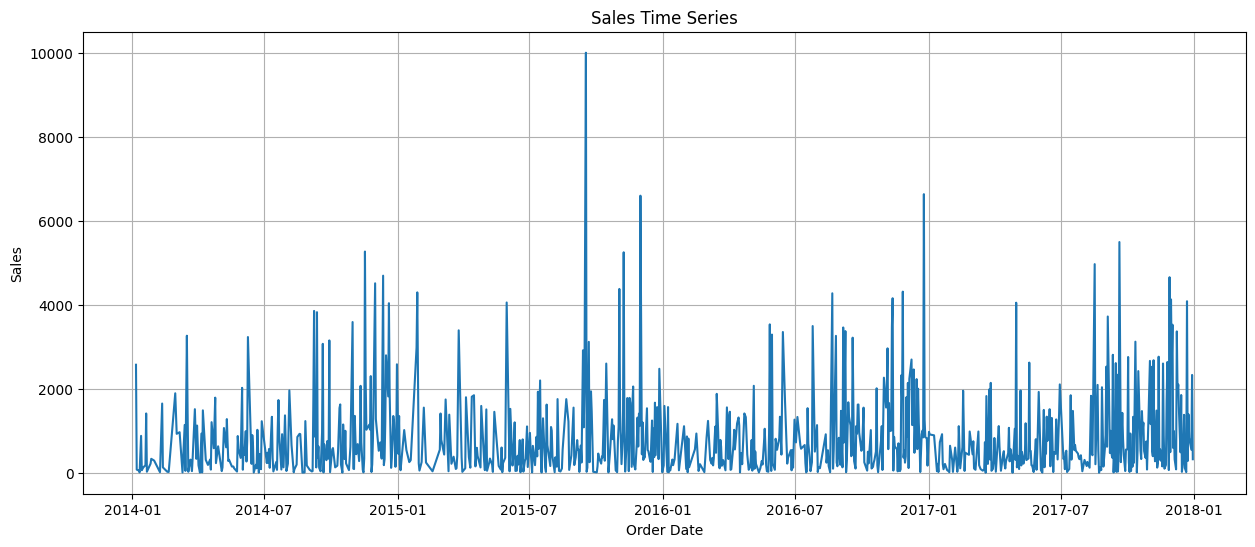

In [25]:
plt.figure(figsize = (15,6))
plt.plot(sales_data['Order Date'], sales_data['Sales'])
plt.xlabel('Order Date')
plt.ylabel('Sales')
plt.title('Sales Time Series')
plt.grid(True)
plt.show()

<Figure size 1200x600 with 0 Axes>

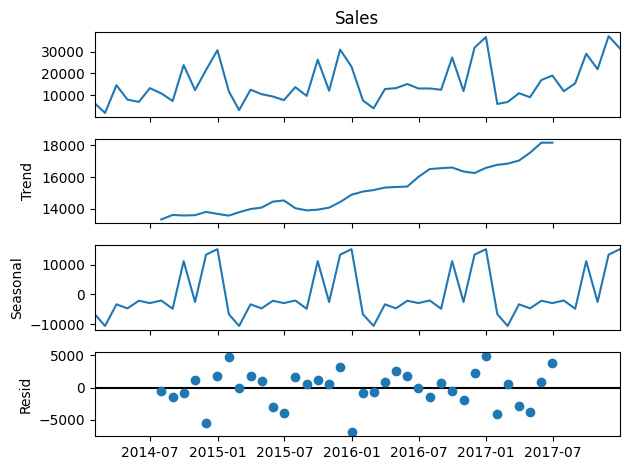

In [27]:
from statsmodels.tsa.seasonal import seasonal_decompose

sales_ts = sales_data.set_index('Order Date')['Sales']

monthly_sales = sales_ts.resample('M').sum()

result = seasonal_decompose(monthly_sales, model='additive')

plt.figure(figsize=(12, 6))
result.plot()
plt.show()
#

In [28]:
monthly_sales = monthly_sales.reset_index()

monthly_sales.columns = ['Date', 'Sales']

In [33]:
train_size = int(len(monthly_sales) * 0.8)

train = monthly_sales[:train_size]
test = monthly_sales[train_size:]

print(f"Training data size: {len(train)}")
print(f"Testing data size: {len(test)}")


Training data size: 38
Testing data size: 10


In [34]:
model = ARIMA(train['Sales'], order=(5,1,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps = len(test))

mae = mean_absolute_error(test['Sales'], forecast)
mse = mean_squared_error(test['Sales'], forecast)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")







Mean Absolute Error: 8168.319111352648
Mean Squared Error: 98532240.45479754


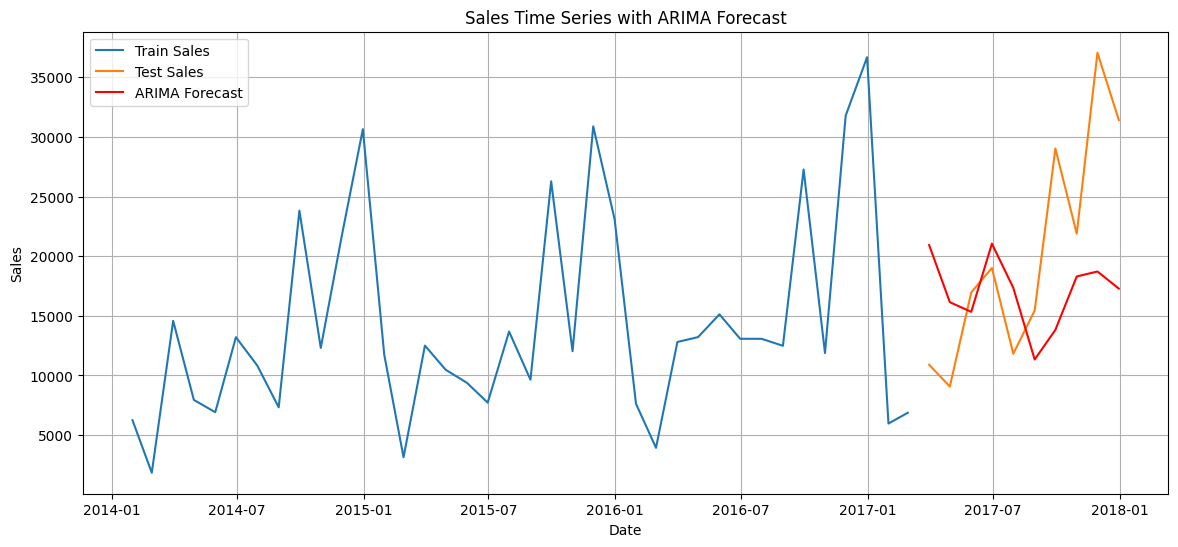

In [35]:
plt.figure(figsize = (14,6))

plt.plot(train['Date'], train['Sales'], label = 'Train Sales')
plt.plot(test['Date'], test['Sales'], label = 'Test Sales')
plt.plot(test['Date'], forecast, color = 'red', label = 'ARIMA Forecast')

plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Sales Time Series with ARIMA Forecast')
plt.legend()
plt.grid(True)
plt.show()

In [36]:
prophet_df = monthly_sales.copy()
prophet_df.columns = ['ds', 'y']


monthly_discount = sales_df.groupby(pd.Grouper(key='Order Date', freq='M'))['Discount'].mean().reset_index()
monthly_discount.columns = ['ds', 'discount']

prophet_df = prophet_df.merge(monthly_discount, on='ds', how='left')

print(prophet_df.head())

          ds          y  discount
0 2014-01-31   6242.525  0.135000
1 2014-02-28   1839.658  0.114286
2 2014-03-31  14573.956  0.230303
3 2014-04-30   7944.837  0.132692
4 2014-05-31   6912.787  0.256250


In [39]:
model_prophet = Prophet(
    yearly_seasonality = True,
    weekly_seasonality = False,
    daily_seasonality = False,
    seasonality_mode = 'additive'
)


model_prophet.add_regressor('discount')

prophet_df['discount'] = prophet_df['discount'].fillna(0)

model_prophet.fit(prophet_df)

In [40]:
future = model_prophet.make_future_dataframe(periods=12, freq='M')


future_discount = prophet_df['discount'].mean()
future['discount'] = future_discount


forecast_prophet = model_prophet.predict(future)

print(forecast_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

           ds          yhat    yhat_lower    yhat_upper
55 2018-08-31  15122.352750  12200.653382  18131.860280
56 2018-09-30  31303.278420  28316.194987  34179.168634
57 2018-10-31  18768.205306  16041.199812  21863.772768
58 2018-11-30  34286.586359  30998.522731  36933.951290
59 2018-12-31  33001.477893  29849.363219  36089.764335


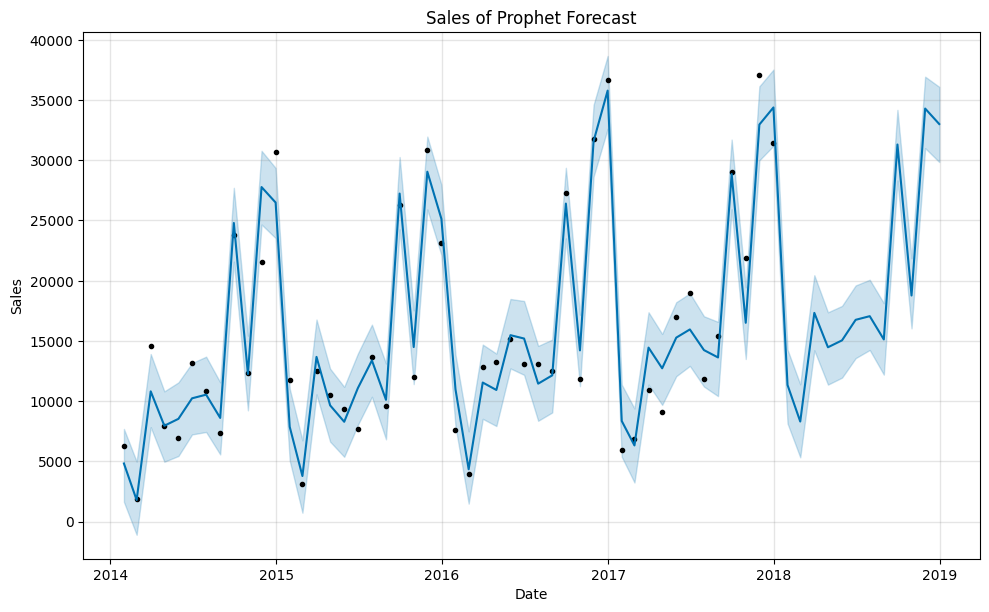

In [42]:
fig1 = model_prophet.plot(forecast_prophet)
plt.title('Sales of Prophet Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

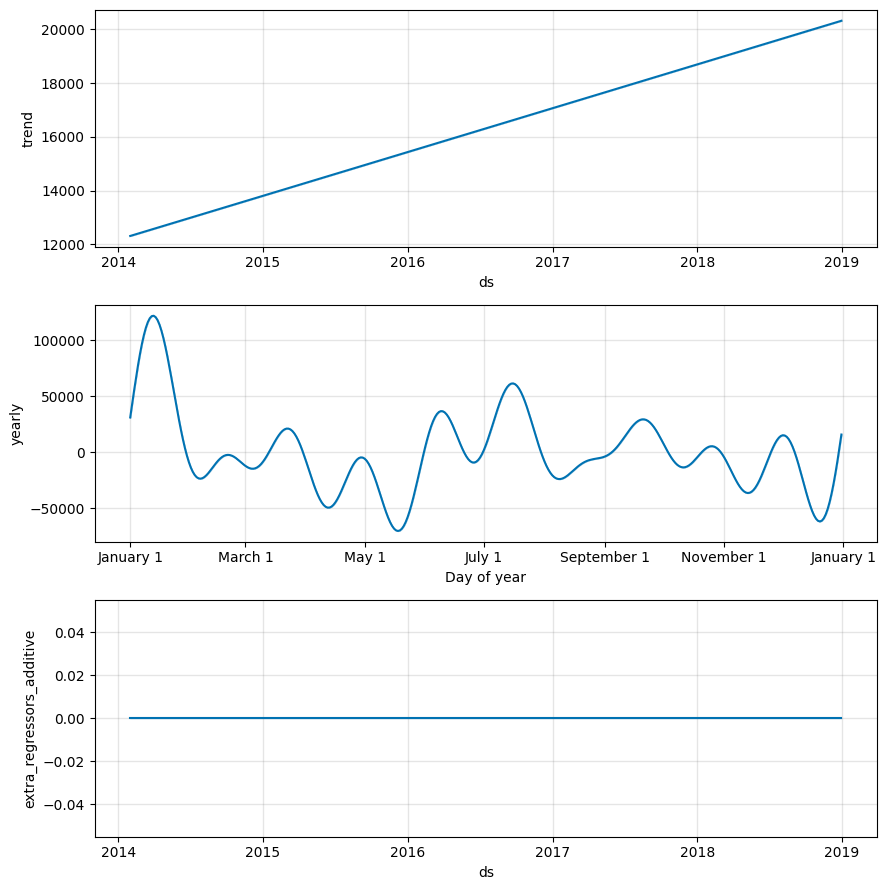

In [43]:
fig2 = model_prophet.plot_components(forecast_prophet)
plt.show()

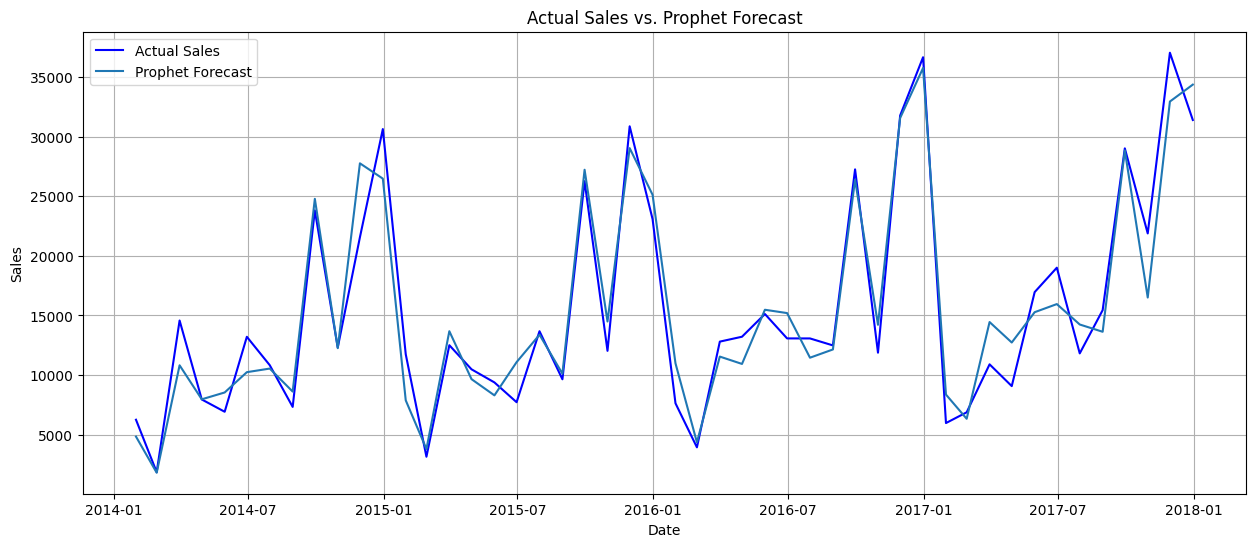

In [45]:
comparison = prophet_df[['ds', 'y']].copy()
comparison = comparison.merge(forecast_prophet[['ds', 'yhat']], on='ds', how='left')



plt.figure(figsize=(15,6))

plt.plot(comparison['ds'], comparison['y'], label='Actual Sales', color='blue')
plt.plot(comparison['ds'], comparison['yhat'], label='Prophet Forecast')


plt.title('Actual Sales vs. Prophet Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

In [47]:
future_forecast = forecast_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

print(future_forecast)

           ds          yhat    yhat_lower    yhat_upper
48 2018-01-31  11341.358650   8152.188182  14272.314881
49 2018-02-28   8308.286234   5336.230974  11395.950336
50 2018-03-31  17327.622727  14220.326477  20453.382904
51 2018-04-30  14472.309431  11372.303671  17375.792324
52 2018-05-31  15046.777087  11950.474969  17906.553209
53 2018-06-30  16750.987403  13568.712026  19604.460564
54 2018-07-31  17053.628186  14246.019626  20077.408163
55 2018-08-31  15122.352750  12200.653382  18131.860280
56 2018-09-30  31303.278420  28316.194987  34179.168634
57 2018-10-31  18768.205306  16041.199812  21863.772768
58 2018-11-30  34286.586359  30998.522731  36933.951290
59 2018-12-31  33001.477893  29849.363219  36089.764335


In [48]:
!pip install tensorflow

In [49]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Prepare data
sales_values = monthly_sales['Sales'].values.reshape(-1,1)

# Scaling
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(sales_values)

# Create sequences
X = []
y = []

sequence_length = 3

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

# Reshape for LSTM
X = X.reshape((X.shape[0], X.shape[1], 1))

# Build model
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(X.shape[1],1)))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse')

# Train model
lstm_model.fit(X, y, epochs=100, batch_size=8, verbose=1)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2156
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1960 
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1765 
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1598 
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1402 
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1244 
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1055 
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0883 
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0736 
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0657 
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0617 
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0603 
Epoch 13/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0609 
Epoch 14/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0608 
Epoch 15/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0600 
Epoch 16/100
6/6 ━━━

In [51]:
arima_mae = mae
arima_rmse = np.sqrt(mse)

# Prophet evaluation
prophet_actual = comparison['y'].dropna()
prophet_pred = comparison['yhat'][:len(prophet_actual)]

prophet_mae = mean_absolute_error(prophet_actual, prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(prophet_actual, prophet_pred))

# Print results
print('========== MODEL PERFORMANCE ==========')
print(f'ARIMA MAE: {arima_mae:.2f}')
print(f'ARIMA RMSE: {arima_rmse:.2f}')
print('---------------------------------------')
print(f'Prophet MAE: {prophet_mae:.2f}')
print(f'Prophet RMSE: {prophet_rmse:.2f}')

========== MODEL PERFORMANCE ==========
ARIMA MAE: 8168.32
ARIMA RMSE: 9926.34
---------------------------------------
Prophet MAE: 1867.54
Prophet RMSE: 2378.50
